In [ ]:
import os
import numpy as np

import jax
import jax.numpy as jnp
from jax import jacfwd, vmap
from functools import partial
from typing import NamedTuple, Sequence, Callable

import flax.linen as nn
import optax
from soap_jax import soap

import time
import scipy.io
import matplotlib.pyplot as plt

from flax import serialization

from Utilities_pinn_burgers1d_statistic import *

Test grid: Nt=513, Nx=513
Interface x=0.50000000, index=256


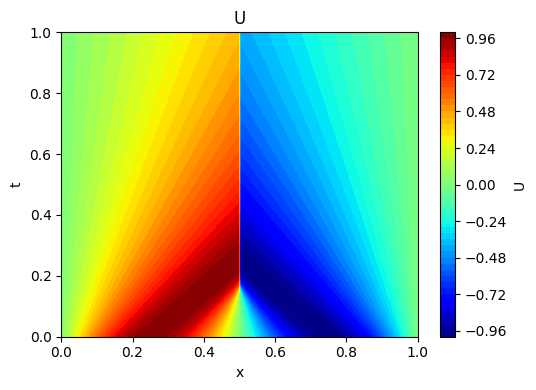

In [2]:
# 1. Data
data = scipy.io.loadmat("burgers_godunov.mat")
#data = scipy.io.loadmat("burgers_riemann.mat")

U0 = jnp.asarray(data["U"][::2,::2])
X0 = jnp.asarray(data["X"][::2,::2])
T0 = jnp.asarray(data["T"][::2,::2])

Nt_test, Nx_test = U0.shape
t_test = T0.reshape(-1)
x_test = X0.reshape(-1)
test_inputs = jnp.stack([t_test, x_test], axis=-1)
test_labels = U0.reshape(-1, 1)

x_unique = np.unique(np.asarray(X0))
interface_idx = int(np.argmin(np.abs(x_unique - 0.5)))
interface_x = float(x_unique[interface_idx])

print(f"Test grid: Nt={Nt_test}, Nx={Nx_test}")
print(f"Interface x={interface_x:.8f}, index={interface_idx}")

plt.figure(figsize=(5.5, 4))
plt.contourf(X0, T0, U0, levels=50, cmap='jet')
plt.colorbar(label='U')
plt.xlabel('x')
plt.ylabel('t')
plt.title('U')
plt.tight_layout()
plt.show()

In [3]:
# 2. Keep the PDE initialization/training keys aligned with TAL-PINN.
seed = 49
save_path = "pinn_burgers_statistic_viscc10.msgpack"

key = jax.random.PRNGKey(seed)
key_pde_init, _, key_train = jax.random.split(key, 3)

# 3. Vanilla PINN on physical coordinates [t, x]
pde_net = FNN_fourier(layer_sizes=[40, 40, 1], fourier_dim=20)
pde_params = pde_net.init(key_pde_init, jnp.ones((2,), dtype=T0.dtype))

pde_optimizer = soap(learning_rate=3.0e-3, b1=0.95, b2=0.95, weight_decay=0.01, precondition_frequency=10, precondition_1d=False)

pde_loss_grad_fn = create_pde_loss_grad_fn(pde_net)
pde_minibatch_fn = create_pde_minibatch_fn(IC_Burgers, BC_Burgers)
eval_fn = create_eval_fn(pde_net, nx_test=Nx_test, interface_idx=interface_idx, interface_mode="drop")

[Vanilla PINN] JIT warm-up finished.
[Vanilla PINN] iter = 00000, time = 0.00s | mse = 1.44e+00, rl2 = 2.43e+00
[Vanilla PINN] iter = 00100, time = 0.57s, loss = 4.32e-01 | mse = 7.71e-02, rl2 = 5.60e-01
[Vanilla PINN] iter = 00200, time = 0.88s, loss = 1.97e-01 | mse = 3.20e-02, rl2 = 3.61e-01
[Vanilla PINN] iter = 00300, time = 1.20s, loss = 3.27e-02 | mse = 1.29e-02, rl2 = 2.30e-01
[Vanilla PINN] iter = 00400, time = 1.51s, loss = 4.04e-03 | mse = 1.00e-02, rl2 = 2.02e-01
[Vanilla PINN] iter = 00500, time = 1.82s, loss = 1.01e-03 | mse = 9.76e-03, rl2 = 1.99e-01
[Vanilla PINN] iter = 00600, time = 2.13s, loss = 6.09e-04 | mse = 9.74e-03, rl2 = 1.99e-01
[Vanilla PINN] iter = 00700, time = 2.44s, loss = 3.39e-04 | mse = 9.68e-03, rl2 = 1.99e-01
[Vanilla PINN] iter = 00800, time = 2.75s, loss = 2.88e-04 | mse = 9.67e-03, rl2 = 1.98e-01
[Vanilla PINN] iter = 00900, time = 3.06s, loss = 2.74e-04 | mse = 9.71e-03, rl2 = 1.99e-01
[Vanilla PINN] iter = 01000, time = 3.37s, loss = 2.39e-04 |

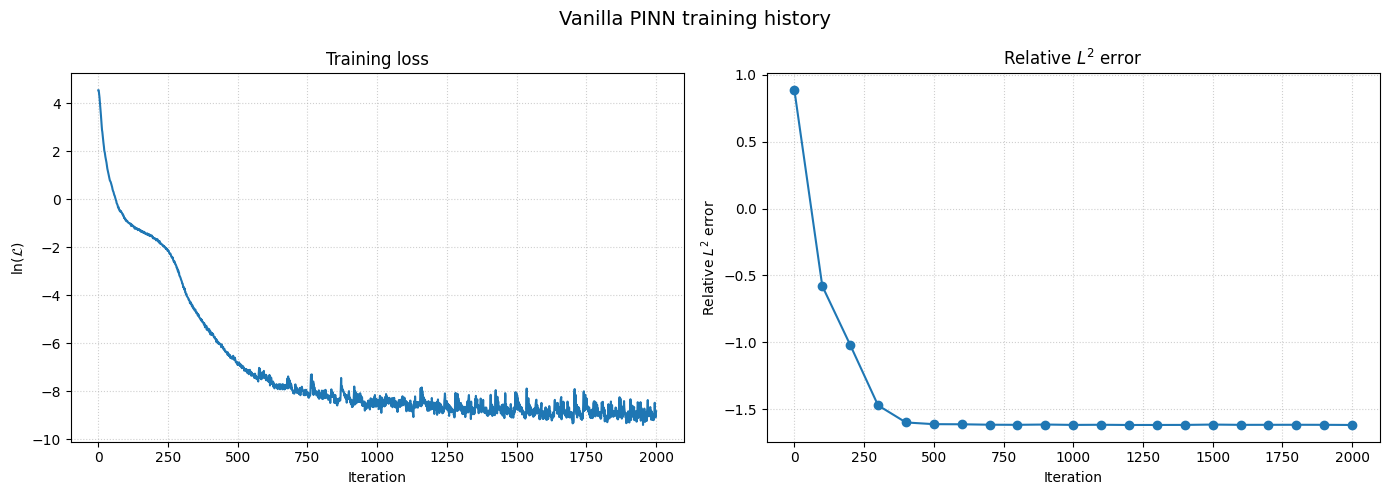

Plotting... Test grid shape: nt=513, nx=513
Interface detected at x = 0.50000000, index = 256
MSE = 9.644646e-03
 RL2 = 1.982430e-01


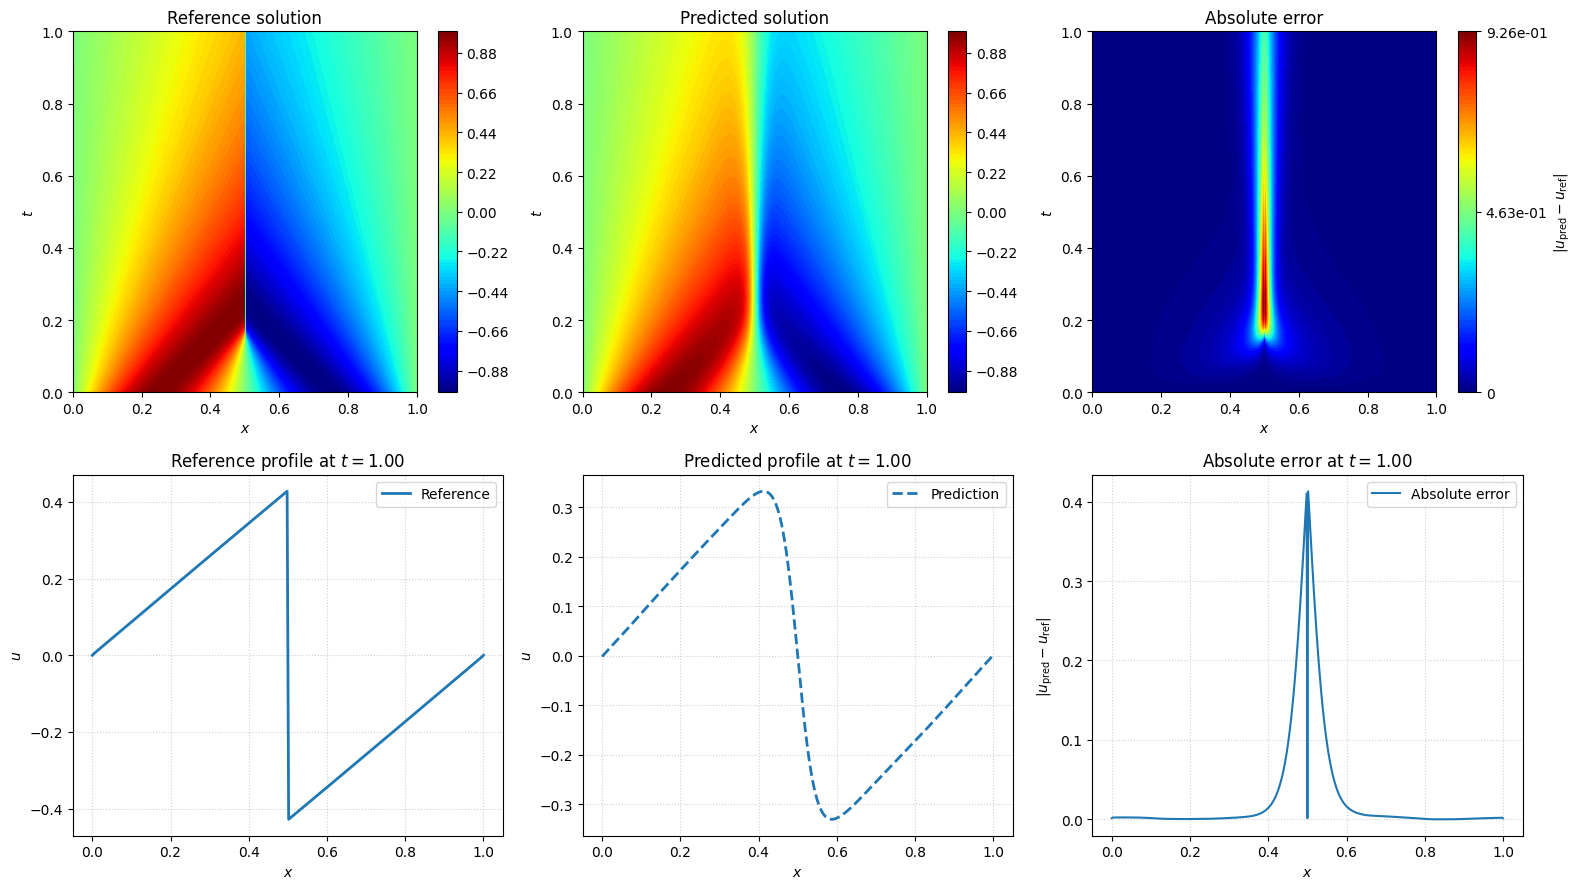

(np.float32(0.009644646), np.float32(0.19824304))

In [4]:
# Stage 1
pde_params, key_train, history_stage1 = train_pde_stage(stage_name="Vanilla PINN", pde_params=pde_params, pde_optimizer=pde_optimizer, pde_loss_grad_fn=pde_loss_grad_fn, pde_minibatch_fn=pde_minibatch_fn,
    eval_fn=eval_fn, test_inputs=test_inputs, test_labels=test_labels,
    key=key_train, nu=1.0e-2, max_iters=2000, pts_pde=10000, pts_ics=1000, pts_bcs=1000, max_runtime=10000.0, eval_every=100)

pde_params_stage1 = pde_params

plot_training_history(history_stage1, metric="rl2", title="Vanilla PINN training history")
plot_evaluation(params=pde_params, model=pde_net, t_test=t_test, x_test=x_test, labels_test=test_labels, interface_x=interface_x, 
    metric_interface_mode="drop", plot_interface_mode="none")

[Vanilla PINN] JIT warm-up finished.
[Vanilla PINN] iter = 00000, time = 0.00s | mse = 9.64e-03, rl2 = 1.98e-01
[Vanilla PINN] iter = 00100, time = 0.34s, loss = 4.28e-01 | mse = 3.68e-02, rl2 = 3.87e-01
[Vanilla PINN] iter = 00200, time = 0.65s, loss = 4.16e-01 | mse = 3.36e-02, rl2 = 3.70e-01
[Vanilla PINN] iter = 00300, time = 0.96s, loss = 3.61e-01 | mse = 2.93e-02, rl2 = 3.46e-01
[Vanilla PINN] iter = 00400, time = 1.28s, loss = 2.84e-01 | mse = 2.40e-02, rl2 = 3.13e-01
[Vanilla PINN] iter = 00500, time = 1.59s, loss = 1.82e-01 | mse = 1.19e-02, rl2 = 2.20e-01
[Vanilla PINN] iter = 00600, time = 1.91s, loss = 1.17e-01 | mse = 9.11e-03, rl2 = 1.93e-01
[Vanilla PINN] iter = 00700, time = 2.22s, loss = 8.54e-02 | mse = 4.24e-03, rl2 = 1.32e-01
[Vanilla PINN] iter = 00800, time = 2.54s, loss = 5.96e-02 | mse = 5.33e-03, rl2 = 1.47e-01
[Vanilla PINN] iter = 00900, time = 2.85s, loss = 5.24e-02 | mse = 5.33e-03, rl2 = 1.47e-01
[Vanilla PINN] iter = 01000, time = 3.17s, loss = 3.59e-02 |

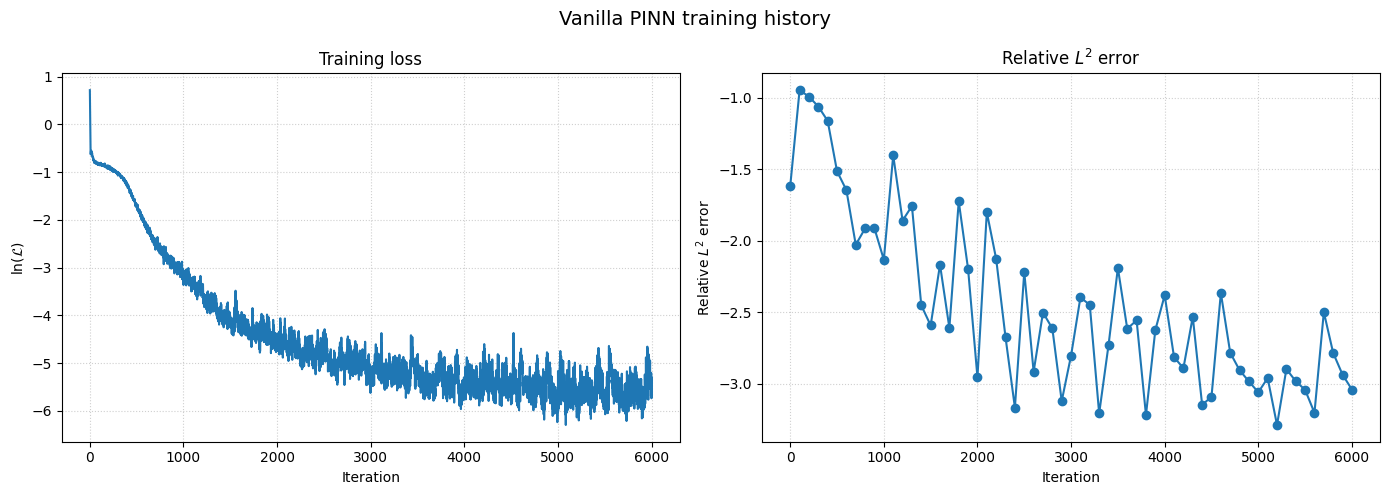

Plotting... Test grid shape: nt=513, nx=513
Interface detected at x = 0.50000000, index = 256
MSE = 5.610262e-04
 RL2 = 4.781304e-02


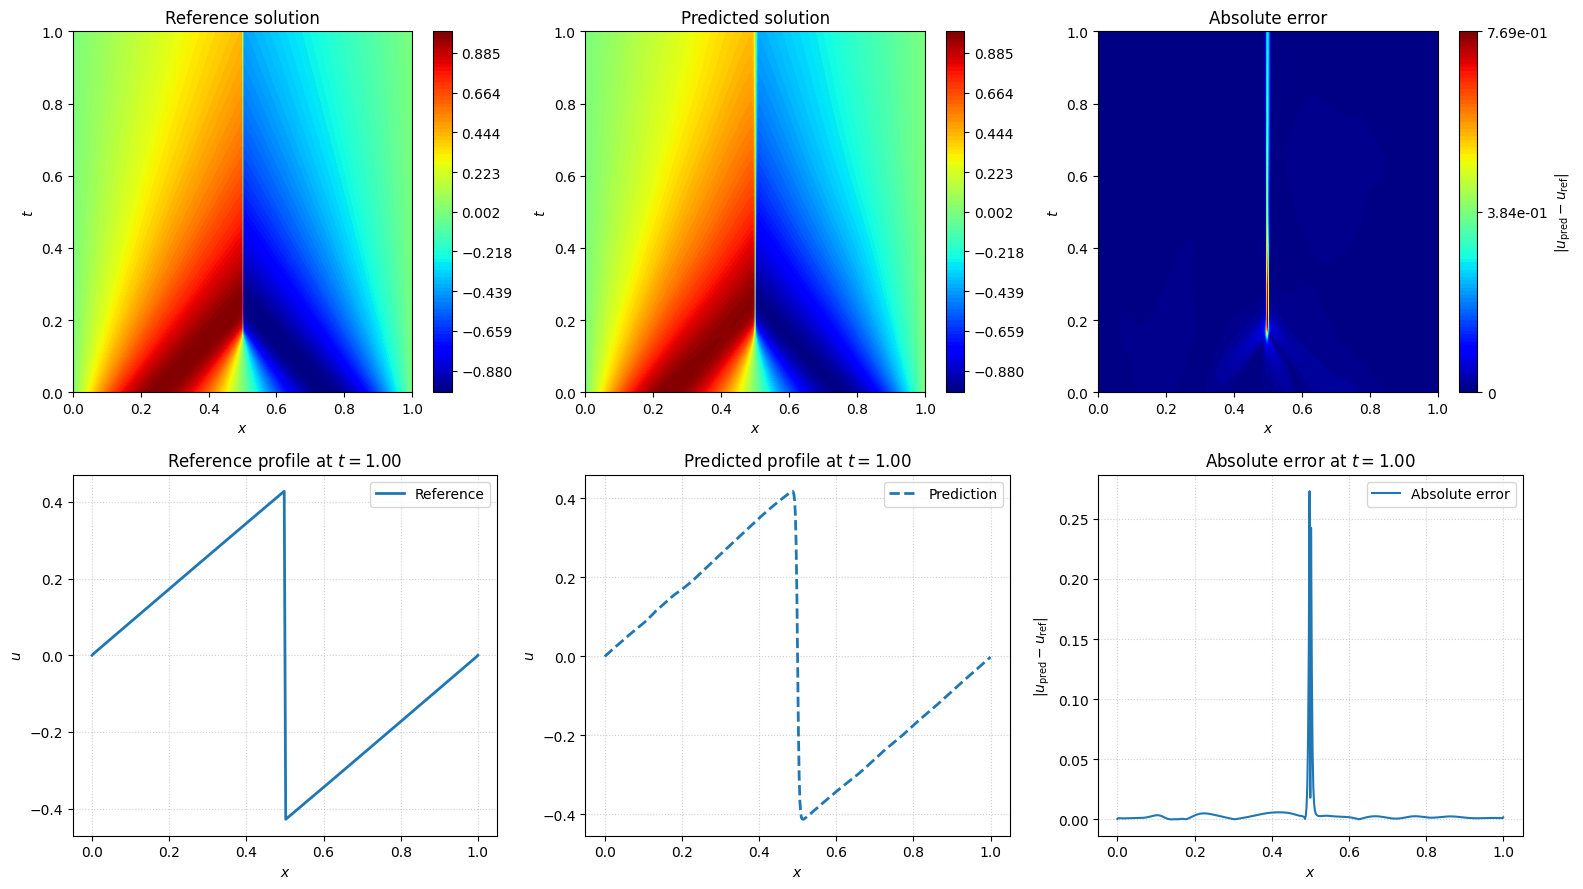

(np.float32(0.0005610262), np.float32(0.047813043))

In [5]:
# Stage 2
pde_params, key_train, history_stage2 = train_pde_stage(stage_name="Vanilla PINN", pde_params=pde_params, pde_optimizer=pde_optimizer, pde_loss_grad_fn=pde_loss_grad_fn, pde_minibatch_fn=pde_minibatch_fn,
    eval_fn=eval_fn, test_inputs=test_inputs, test_labels=test_labels,
    key=key_train, nu=1.0e-3, max_iters=6000, pts_pde=10000, pts_ics=1000, pts_bcs=1000, max_runtime=10000.0, eval_every=100)

pde_params_stage2 = pde_params

plot_training_history(history_stage2, metric="rl2", title="Vanilla PINN training history")
plot_evaluation(params=pde_params, model=pde_net, t_test=t_test, x_test=x_test, labels_test=test_labels, interface_x=interface_x, 
    metric_interface_mode="drop", plot_interface_mode="none")

[Vanilla PINN] JIT warm-up finished.
[Vanilla PINN] iter = 00000, time = 0.00s | mse = 5.61e-04, rl2 = 4.78e-02
[Vanilla PINN] iter = 00100, time = 0.31s, loss = 4.96e-01 | mse = 4.23e-02, rl2 = 4.15e-01
[Vanilla PINN] iter = 00200, time = 0.60s, loss = 4.69e-01 | mse = 3.60e-02, rl2 = 3.83e-01
[Vanilla PINN] iter = 00300, time = 0.90s, loss = 4.39e-01 | mse = 3.64e-02, rl2 = 3.85e-01
[Vanilla PINN] iter = 00400, time = 1.20s, loss = 4.59e-01 | mse = 4.48e-02, rl2 = 4.27e-01
[Vanilla PINN] iter = 00500, time = 1.49s, loss = 4.41e-01 | mse = 3.90e-02, rl2 = 3.98e-01
[Vanilla PINN] iter = 00600, time = 1.79s, loss = 4.39e-01 | mse = 4.17e-02, rl2 = 4.12e-01
[Vanilla PINN] iter = 00700, time = 2.08s, loss = 4.43e-01 | mse = 3.87e-02, rl2 = 3.97e-01
[Vanilla PINN] iter = 00800, time = 2.38s, loss = 4.45e-01 | mse = 3.62e-02, rl2 = 3.84e-01
[Vanilla PINN] iter = 00900, time = 2.67s, loss = 4.34e-01 | mse = 3.52e-02, rl2 = 3.79e-01
[Vanilla PINN] iter = 01000, time = 2.96s, loss = 4.29e-01 |

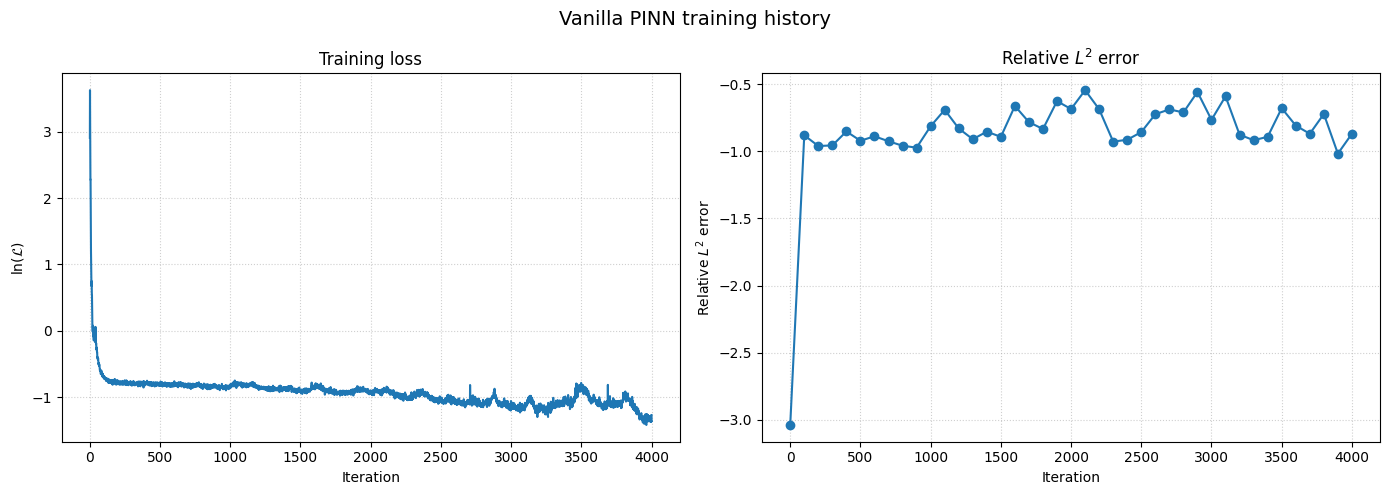

Plotting... Test grid shape: nt=513, nx=513
Interface detected at x = 0.50000000, index = 256
MSE = 4.326123e-02
 RL2 = 4.198597e-01


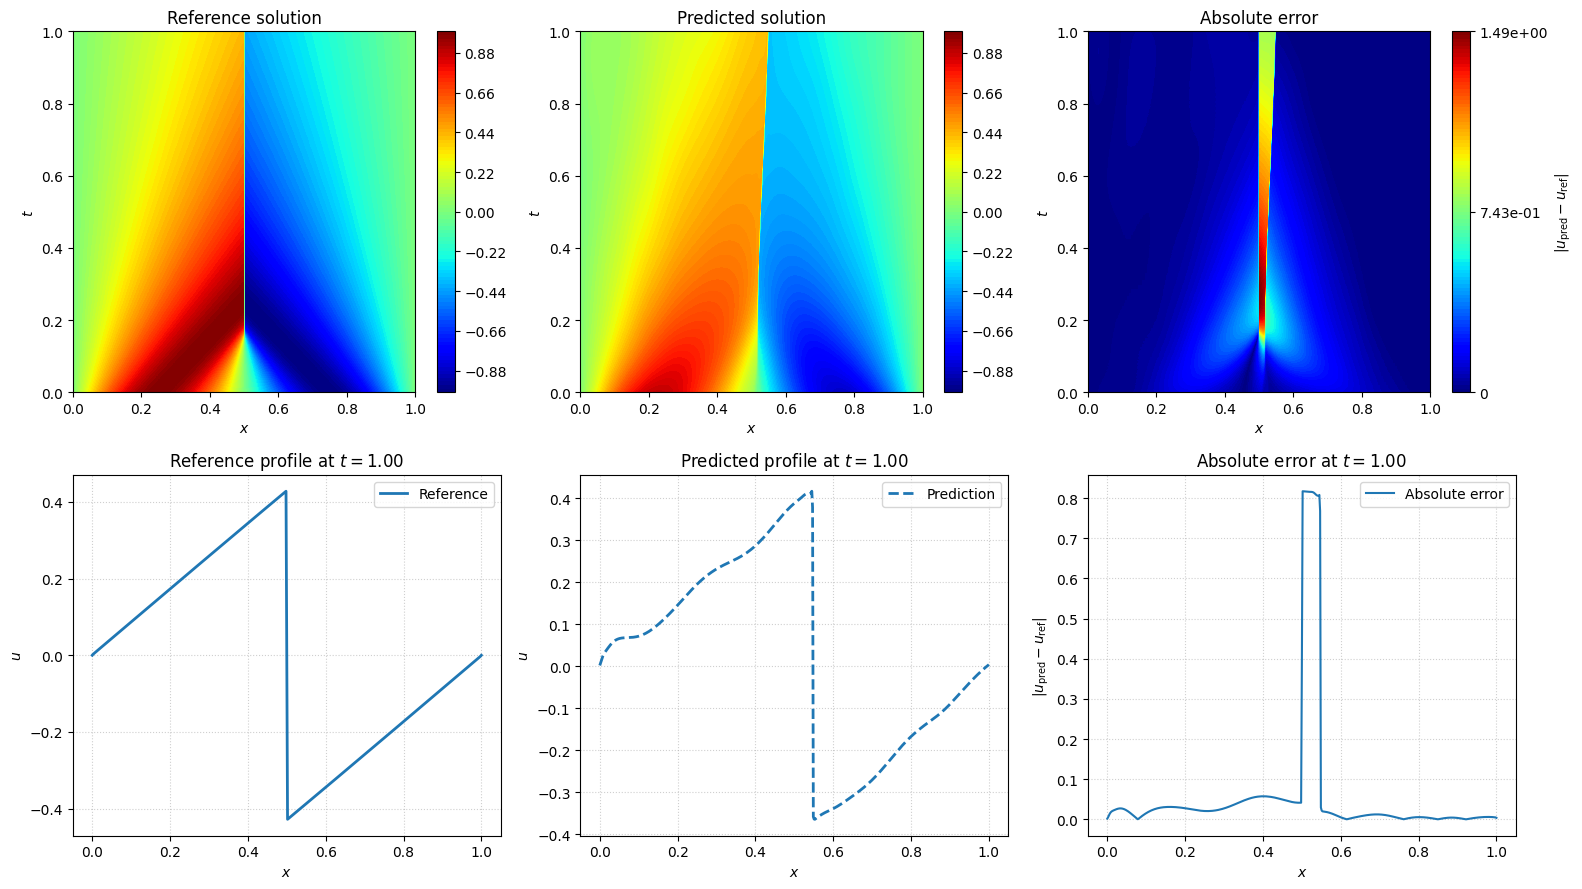

(np.float32(0.043261234), np.float32(0.41985974))

In [6]:
# Stage 3
pde_params, key_train, history_stage3 = train_pde_stage(stage_name="Vanilla PINN", pde_params=pde_params, pde_optimizer=pde_optimizer, pde_loss_grad_fn=pde_loss_grad_fn, pde_minibatch_fn=pde_minibatch_fn,
    eval_fn=eval_fn, test_inputs=test_inputs, test_labels=test_labels,
    key=key_train, nu=1.0e-4, max_iters=4000, pts_pde=10000, pts_ics=1000, pts_bcs=1000, max_runtime=10000.0, eval_every=100)

pde_params_stage3 = pde_params

plot_training_history(history_stage3, metric="rl2", title="Vanilla PINN training history")
plot_evaluation(params=pde_params, model=pde_net, t_test=t_test, x_test=x_test, labels_test=test_labels, interface_x=interface_x, 
    metric_interface_mode="drop", plot_interface_mode="none")

In [7]:
def save_training_results(pde_params_by_stage, pde_histories_by_stage,
    checkpoint_path="pinn_adsamp_burgers_statistic.msgpack", history_path=None):
    """Save all three adaptive-sampling PINN stages and their histories."""
    stage_names = ("stage1", "stage2", "stage3")
    history_keys = (
        "iter", "loss", "train_time",
        "eval_iter", "eval_train_time", "mse", "rl2",
    )

    if set(pde_params_by_stage) != set(stage_names):
        raise ValueError(f"pde_params_by_stage keys must be {stage_names}")
    if set(pde_histories_by_stage) != set(stage_names):
        raise ValueError(f"pde_histories_by_stage keys must be {stage_names}")

    histories = {}
    for stage_name in stage_names:
        history = pde_histories_by_stage[stage_name]
        missing_keys = [name for name in history_keys if name not in history]
        if missing_keys:
            raise ValueError(f"{stage_name} history is missing keys: {missing_keys}")
        histories[stage_name] = {
            name: np.asarray(history[name]) for name in history_keys
        }

    checkpoint = {
        "format_version": 1,
        "pde_params": jax.device_get({
            name: pde_params_by_stage[name] for name in stage_names
        }),
        "pde_histories": histories,
    }

    checkpoint_path = os.path.abspath(checkpoint_path)
    os.makedirs(os.path.dirname(checkpoint_path), exist_ok=True)
    checkpoint_tmp = checkpoint_path + ".tmp"
    with open(checkpoint_tmp, "wb") as f:
        f.write(serialization.to_bytes(checkpoint))
    os.replace(checkpoint_tmp, checkpoint_path)

    if history_path is None:
        history_path = os.path.splitext(checkpoint_path)[0] + "_history.npz"
    history_path = os.path.abspath(history_path)
    os.makedirs(os.path.dirname(history_path), exist_ok=True)

    history_arrays = {
        f"{stage_name}_{name}": values
        for stage_name, history in histories.items()
        for name, values in history.items()
    }
    history_tmp = history_path + ".tmp"
    with open(history_tmp, "wb") as f:
        np.savez_compressed(f, **history_arrays)
    os.replace(history_tmp, history_path)

    print(f"Training checkpoint saved to: {checkpoint_path}")
    print(f"Training histories saved to: {history_path}")

In [8]:
save_training_results(
    pde_params_by_stage={
        "stage1": pde_params_stage1,
        "stage2": pde_params_stage2,
        "stage3": pde_params_stage3,
    },
    pde_histories_by_stage={
        "stage1": history_stage1,
        "stage2": history_stage2,
        "stage3": history_stage3,
    },
    checkpoint_path=save_path,
)

Training checkpoint saved to: /home/DG21210022/Amon/tal/burgers/pinn_burgers_statistic_viscc10.msgpack
Training histories saved to: /home/DG21210022/Amon/tal/burgers/pinn_burgers_statistic_viscc10_history.npz
